# 01 — Hill Climbing y Random Restart

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

Al finalizar este notebook podrás:

- representar un problema de optimización mediante estados, vecinos y una función objetivo;
- implementar **Hill Climbing** para un problema discreto;
- identificar óptimos locales y mesetas;
- usar **Random Restart** para mejorar la exploración.

En los notebooks nos concentraremos en experimentar. La formalización y las propiedades de los algoritmos se presentan en las diapositivas.

## 1. Problema de ubicación de hospitales

Tenemos una cuadrícula con varias casas y queremos ubicar $k$ hospitales. El costo de una solución es la suma de la distancia de cada casa al hospital más cercano.

Usaremos distancia Manhattan:

$$
d((r_1,c_1),(r_2,c_2)) = |r_1-r_2|+|c_1-c_2|
$$

El problema es

$$
\min_{H} \sum_{c\in C}\min_{h\in H}d(c,h)
$$

- $C$: conjunto de casas.
- $H$: conjunto de hospitales.
- Un vecino se obtiene moviendo un hospital una celda arriba, abajo, izquierda o derecha.

![HillClimbing](https://drive.google.com/uc?export=view&id=1Vb7q8PCqTw-8WkalRWqtB86ovmLhrU1r)


In [ ]:
import random #sirve para generar cosas aleatorias
import numpy as np
import matplotlib.pyplot as plt#sirve para hacer gráficos

SEED = 8 #semilla aleatoria que nos permite controlar la aleatoriedad
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
def manhattan(a, b): #se define la funcion de manhattan
    return abs(a[0] - b[0]) + abs(a[1] - b[1]) #usa fórmula manhattan


def total_cost(houses, hospitals):  #se define la funcion del costo total
    return sum(min(manhattan(house, hospital) for hospital in hospitals)
               for house in houses) #Para cada casa, busca el hospital más cercano, obtiene esa distancia, suma todas las distancias.


def plot_state(height, width, houses, hospitals, title=None): #se crea cuadricula
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        hr, hc = zip(*houses)
        ax.scatter(hc, hr, marker='s', s=110, label='Casas')
    if hospitals:
        rr, cc = zip(*hospitals)
        ax.scatter(cc, rr, marker='P', s=180, label='Hospitales')

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f'Costo = {total_cost(houses, hospitals)}')
    plt.tight_layout()
    plt.show()

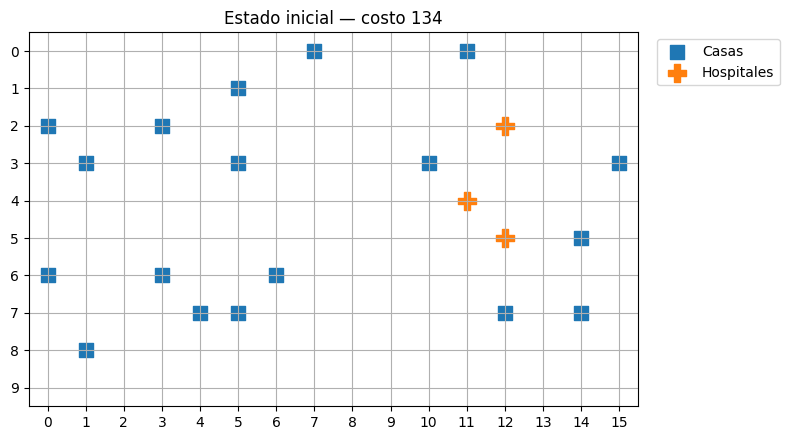

In [ ]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [(r, c) for r in range(HEIGHT) for c in range(WIDTH)] #Para cada fila, recorre todas las columnas y guarda la posición
houses = set(random.sample(all_cells, NUM_HOUSES)) #set no permite elementos repetidos
available = list(set(all_cells) - houses)#de todas las celdas posibles elimina las que están ocupadas por casas."
initial_hospitals = set(random.sample(available, NUM_HOSPITALS))

plot_state(HEIGHT, WIDTH, houses, initial_hospitals,
           title=f'Estado inicial — costo {total_cost(houses, initial_hospitals)}')

## 2. Vecindario

Para generar estados vecinos moveremos **un hospital a la vez** hacia una celda adyacente disponible.

In [ ]:
def neighbors_of_state(height, width, houses, hospitals):
    neighbors = [] #creamos lista vacía para guardar todos los vecinos
    #moves = [(-1, 0), (1, 0), (0, -1), (0, 1)] #los movimientos posibles (arriba disminuimos fila, abajo aumentamos fila, izquierda disminuimos columna y derecha aumentamos columna))
    moves = [ (-1, 0), (1, 0), (0, -1), (0, 1),(-2, 0), (2, 0), (0, -2), (0, 2)]#incluimos movimientos de 2 celdas (Actividad 3)

    #permite explorar más estados y encontrar soluciones de menor costo pero de igual manera aumenta el número de evaluaciones necesarias.
    #no elimina completamente el problema de los óptimos locales.

    for hospital in hospitals:
        for dr, dc in moves: #Para ese hospital, prueba los cuatro movimientos posibles
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width): #Esto verifica que la nueva posición esté dentro de los límites
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)#Esto crea una copia del estado actual
            new_state.remove(hospital)#quitamos el hospital de su posición original
            new_state.add(candidate)#lo ponemos en la nueva posición
            neighbors.append(new_state)#agrega este elemento al final de la lista

    return neighbors

neighbors = neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)
print('Número de vecinos:', len(neighbors))
print('Costo actual:', total_cost(houses, initial_hospitals))
print('Mejor costo vecino:', min(total_cost(houses, n) for n in neighbors))

Número de vecinos: 22
Costo actual: 134
Mejor costo vecino: 114


## 3. Hill Climbing

En cada iteración:

1. generamos todos los vecinos;
2. calculamos sus costos;
3. nos movemos al vecino con menor costo;
4. detenemos el proceso cuando ningún vecino mejora la solución.

Costo inicial: 134
Costo final: 62
Iteraciones con mejora: 8


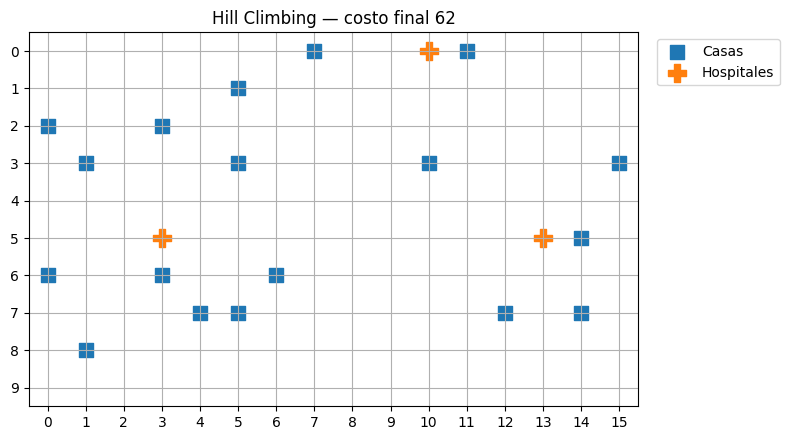

In [ ]:
def hill_climbing(height, width, houses, num_hospitals, initial_state=None,
                  max_iterations=200, rng=None): #empieza con un estado inicial nulo y máximo número de veces que permitimos que el algoritmo intente mejorar es 200
    rng = rng or random.Random()
    available = list(set((r, c) for r in range(height) for c in range(width)) - houses)
    current = set(initial_state) if initial_state is not None else set(rng.sample(available, num_hospitals)) #crea estado inicial
    history = [total_cost(houses, current)] #es una lista que guarda la historia de costos
    states = [set(current)] #guarda las posiciones de los hospitales en cada paso

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(height, width, houses, current)#genera vecinos
        if not neighbors:
            break

        costs = [total_cost(houses, n) for n in neighbors] #calcula costo de cada vecino
        best_cost = min(costs) #menor costo entre todos los vecinos
        current_cost = history[-1] #-1 último elemento de la lista

        if best_cost >= current_cost: #solo acepta una mejora estricta
            break

        best_neighbors = [n for n, c in zip(neighbors, costs) if c == best_cost] #zip permite recorrer dos listas al mismo tiempo
        current = set(rng.choice(best_neighbors))#rng.choice() escoge aleatoriamente uno de los mejores vecinos si hay 2 iguales
        history.append(best_cost)
        states.append(set(current))#guardamos la nueva configuración reconstruir el camino que tomó el algoritmo

    return current, history, states

solution, history, states = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(SEED)
)

print('Costo inicial:', history[0])
print('Costo final:', history[-1])
print('Iteraciones con mejora:', len(history) - 1)
plot_state(HEIGHT, WIDTH, houses, solution,
           title=f'Hill Climbing — costo final {history[-1]}')

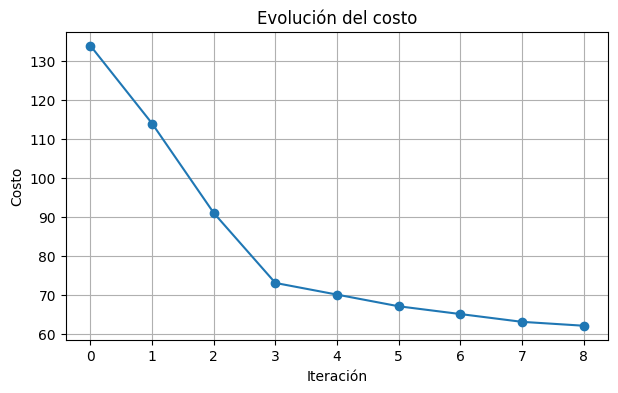

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(range(len(history)), history, marker='o')
plt.xlabel('Iteración')
plt.ylabel('Costo')
plt.title('Evolución del costo')
plt.grid(True)
plt.show()

## 4. Random Restart

Una corrida de Hill Climbing puede terminar en un óptimo local. Random Restart ejecuta el algoritmo desde diferentes estados iniciales y conserva la mejor solución encontrada.

Mejor costo: 56
Reinicio ganador: 1


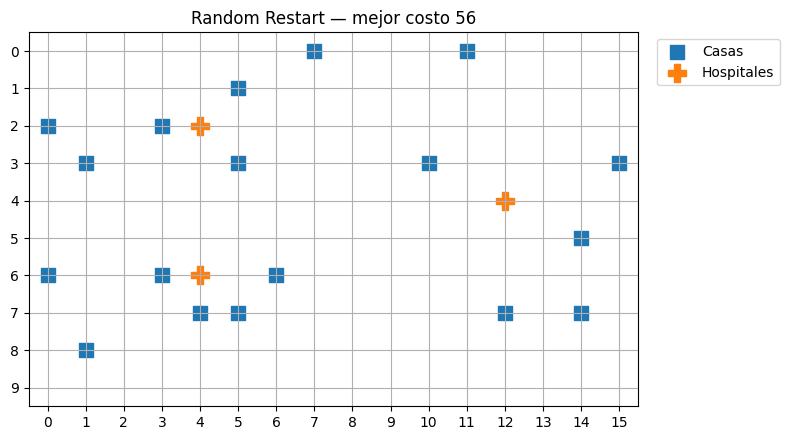

In [ ]:
def random_restart(height, width, houses, num_hospitals, restarts=30, seed=0): #ejecuta Hill Climbing 30 veces
    master_rng = random.Random(seed)#creamos un generador aleatorio principal
    runs = []#creamos una lista para guardar los resultados de cada ejecución
    best = None

    for restart in range(restarts):
        run_seed = master_rng.randrange(10**9)#Esto genera una semilla diferente para cada ejecución. Entonces cada Hill Climbing puede comenzar desde una configuración diferente
        solution, history, _ = hill_climbing(
            height, width, houses, num_hospitals,
            rng=random.Random(run_seed)
        )
        record = {
            'restart': restart,
            'solution': solution,
            'initial_cost': history[0],
            'final_cost': history[-1],
            'iterations': len(history) - 1
        }
        runs.append(record)
        if best is None or record['final_cost'] < best['final_cost']:
            best = record

    return best, runs

best, runs = random_restart(HEIGHT, WIDTH, houses, NUM_HOSPITALS, restarts=40, seed=SEED)
print('Mejor costo:', best['final_cost'])
print('Reinicio ganador:', best['restart'])
plot_state(HEIGHT, WIDTH, houses, best['solution'],
           title=f'Random Restart — mejor costo {best["final_cost"]}')

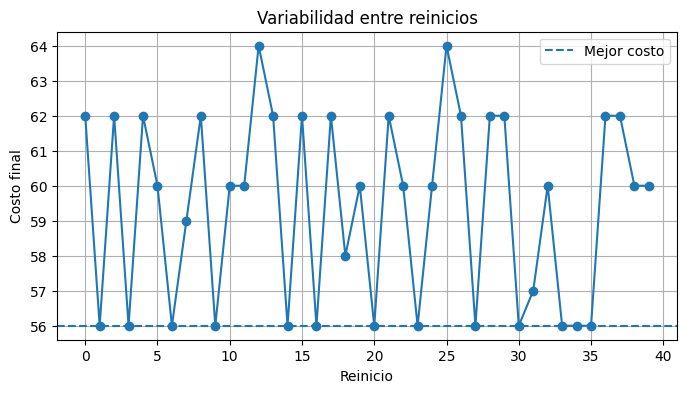

In [ ]:
final_costs = [run['final_cost'] for run in runs]
plt.figure(figsize=(8, 4)) #Crea el espacio donde vamos a dibujar la gráfica
plt.plot(final_costs, marker='o')#Esto dibuja la evolución del costo
plt.axhline(min(final_costs), linestyle='--', label='Mejor costo')
plt.xlabel('Reinicio')
plt.ylabel('Costo final')
plt.title('Variabilidad entre reinicios')
plt.legend()
plt.grid(True)
plt.show() #gráfica iteración vs.costo

## Actividades

### Actividad 1 — Distancia euclídea

Modifica la función de costo para usar

$$
d(a,b)=\sqrt{(a_r-b_r)^2+(a_c-b_c)^2}
$$

Compara la ubicación de los hospitales y el costo con la distancia Manhattan.

In [ ]:
# TODO: implementa la distancia euclídea y una nueva función de costo.
import math
def euclidean(a, b):
  return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2
    )

def total_cost_euclidean(houses, hospitals):
    return sum(min(euclidean(house, hospital) for hospital in hospitals)#por cada casa encuentra distancia a hospital, escoge la mejor, repite para la siguiente casa, suma y luego costo final
        for house in houses
    )

    #Al utilizar distancia euclídea se modifica la función objetivo del problema.
    #Por esta razón, Hill Climbing puede encontrar una distribución de hospitales diferente a la obtenida con Manhattan.
    # La diferencia se debe a que cada métrica asigna costos diferentes a las mismas posiciones.

### Actividad 2 — Número de hospitales

Ejecuta Random Restart para $k\in\{1,2,3,4,5\}$. Registra el mejor costo y discute si agregar hospitales produce siempre la misma reducción.

In [ ]:
results = []
for k in range(1, 6):
   best_k, _ = random_restart(
        HEIGHT,
        WIDTH,
        houses,
        k,
        restarts=40,
        seed=SEED
    )
   results.append((k, best_k['final_cost']))

results
#El mejor costo es con 5 hospitales con un costo total de 37.
#El costo mínimo tiende a disminuir porque tenemos más hospitales disponibles para atender las casas.
#Cada casa puede elegir entre más hospitales y, por lo tanto, la distancia hasta su hospital más cercano puede mantenerse o reducirse.
#No siempre se produce la misma reducción, puesto que, a medida que agregamos hospitales, muchas casas ya están relativamente cerca de uno.
#Por lo tanto, los hospitales adicionales tienen menos oportunidades de producir una mejora grande.

[(1, 114), (2, 75), (3, 56), (4, 44), (5, 37)]

### Actividad 3 — Diseño del vecindario

Actualmente un hospital solo se mueve una celda. Crea un vecindario que permita movimientos de hasta dos celdas. ¿Mejora el resultado? ¿Cuánto aumenta el número de vecinos evaluados? R/ Estos nuevos movimientos nos permiten explorar más estados y encontrar soluciones de menor costo pero de igual manera aumenta el número de evaluaciones necesarias. Cabe recalcar que no elimina completamente el problema de los óptimos locales. En el código original hay 3 hospitales, por lo que inicialmente se evalúan hasta 12 vecinos (3 x 4 movimientos) . Con el nuevo vecindario se pasan a evaluar 24 vecinos( 3 hospitales x 8 movimientos), es decir, el doble. Esto mejora la exploración, pero aumenta el tiempo de cálculo.

## Preguntas de cierre

1. ¿Por qué Hill Climbing no necesita construir todo el espacio de búsqueda?
R/ El Hill Climbing realiza una búsqueda local, no analiza todas las posibles configuraciones de los hospitales. Analiza únicamente los vecinos del estado actual lo cuál ayuda a reducir la cantidad de estados a analizar.
2. ¿El resultado depende del estado inicial?
R/ Sí, el Hill Climbing parte de un estado inicial y a partir de este evalúa su vecindario y se mueve sólo si algún estado vecino es mejor. Un punto de partida distinto puede generar un óptimo local diferente por lo que el resultado puede cambiar dependiendo del punto inicial del que se parta.
3. ¿Random Restart garantiza encontrar el óptimo global?
R/ No, Random Restart ejecuta Hill Climbing desde distintos estados iniciales para después comparar los óptimos locales y encontrar el mejor. Esto no garantiza que se haya explorado todo el espacio de búsqueda por lo que no se puede afirmar que encentre el óptimo global del problema.
4. ¿Qué información se pierde al conservar únicamente el mejor vecino?
R/ Al conservar únicamente el mejor vecino se puede perder información de otros caminos posibles. Si se escoge el vecino con mejor costo para el problema sepierden los caminos de los otros vecinos que no fueron escogidos que a lo mejor pudieron haber tenido otros vecinos con un mejor costo que el que fue seleccionado inicialmente. Por esto puede quedar atrapado en óptimos locales.